# NAMA      : SRI ZUL'AINI ULYA
# NIM       : F1D02410096
# KELOMPOK  : 10

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

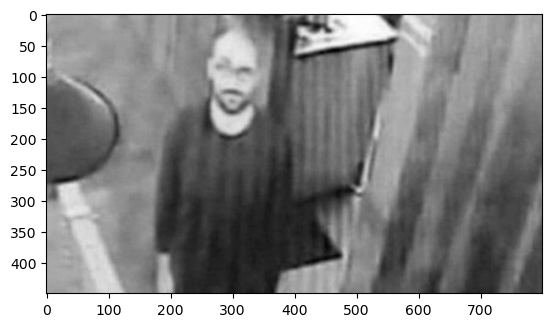

In [4]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('on')

cctv = plt.imread("backup.jpg")
img_gray = cv.cvtColor(cctv, cv.COLOR_RGB2GRAY)
if img_gray.dtype != np.uint8:
    img_gray = (img_gray * 255).astype(np.uint8)

show(img_gray)

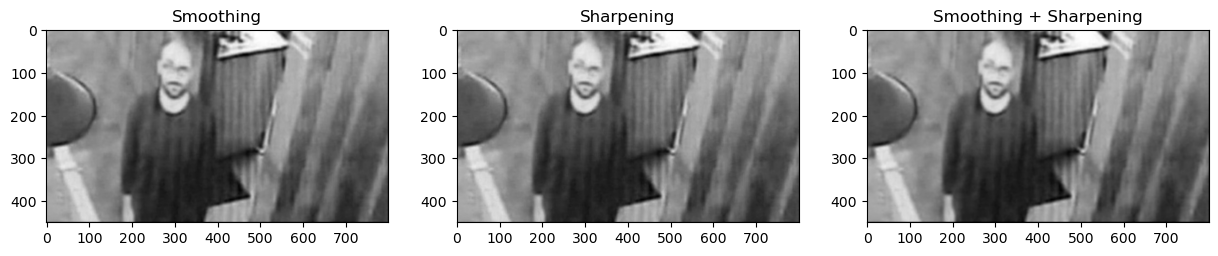

In [28]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

img_smoothed = convolution(img_gray, kernelSmoothing)
img_sharpened = convolution(img_gray, kernelSharpening)
img_smootpened = convolution(img_smoothed, kernelSharpening)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
show(img_smoothed, 'Smoothing')

plt.subplot(1, 3, 2)
show(img_sharpened, 'Sharpening')

plt.subplot(1, 3, 3)
show(img_smootpened, 'Smoothing + Sharpening')

In [42]:
def filter(img, size, mode):
    height, width = img.shape
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = int(np.mean(region))
        
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = int(np.median(region))
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas


In [ ]:
img_mean = filter(img_smootpened, 3, 'mean')
img_modus = filter(img_smootpened, 3, 'modus')
img_median = filter(img_smootpened, 3, 'median')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
show(img_mean, 'Mean')

plt.subplot(1, 3, 2)
show(img_modus, 'Modus')

plt.subplot(1, 3, 3)
show(img_median, 'Median')

OverflowError: Python integer 257 out of bounds for uint8

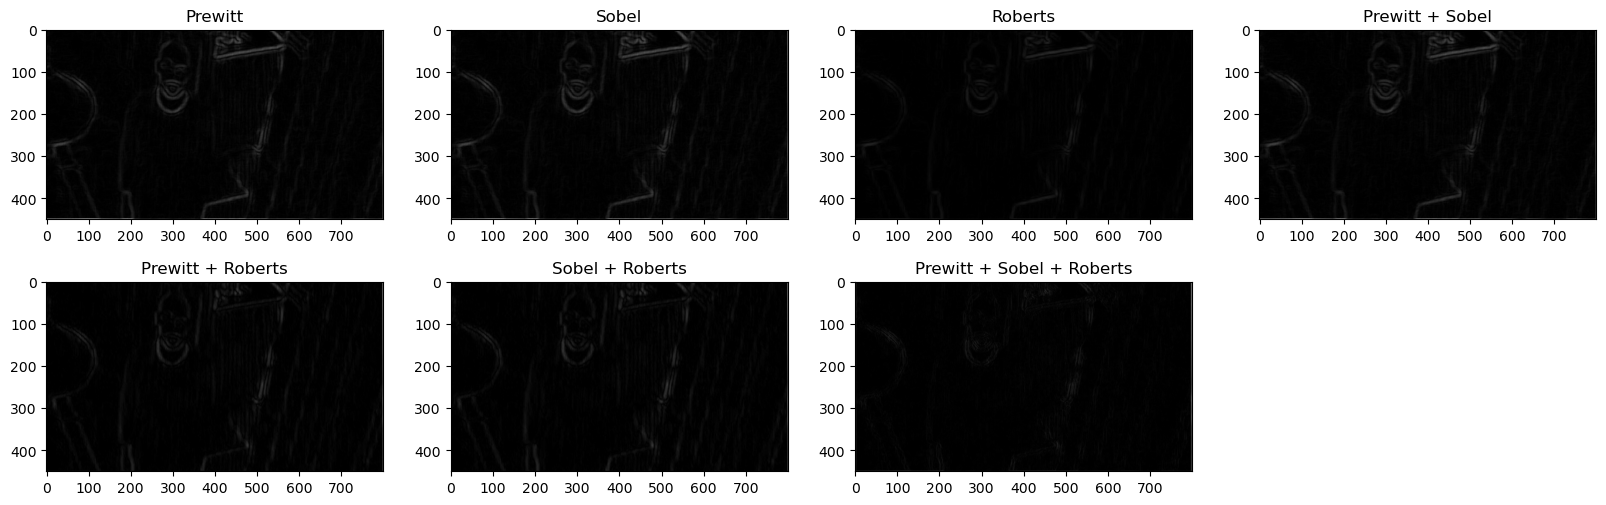

In [40]:
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

prewitt = edge(img_sharpened, prewittx, prewitty)
sobel = edge(img_sharpened, sobelx, sobely)
roberts = edge(img_sharpened, robertsx, robertsy)
prebel = edge(img_sharpened, prewittx, sobely)
prerob = edge(img_sharpened, prewittx, robertsy)
belrob = edge(img_sharpened, sobelx, robertsy)
prebelrob = edge(prewitt, sobelx, robertsy)

plt.figure(figsize=(20, 6))

plt.subplot(2, 4, 1)
show(prewitt, 'Prewitt')

plt.subplot(2, 4, 2)
show(sobel, 'Sobel')

plt.subplot(2, 4, 3)
show(roberts, 'Roberts')

plt.subplot(2, 4, 4)
show(prebel, 'Prewitt + Sobel')

plt.subplot(2, 4, 5)
show(prerob, 'Prewitt + Roberts')

plt.subplot(2, 4, 6)
show(belrob, 'Sobel + Roberts')

plt.subplot(2, 4, 7)
show(prebelrob, 'Prewitt + Sobel + Roberts')